# READ ME

**This project focuses on predicting house prices using various machine learning models. We start by loading and visualizing the house price dataset. Initially, a simple linear regression model is trained using 'area' and 'rooms' features. Subsequently, we explore polynomial features to enhance the model's performance and finally, introduce a more advanced Random Forest Regressor to achieve higher prediction accuracy.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model


In [ ]:
df = pd.read_csv("/content/house_price.csv")
df

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900
5,1985,4,299900
6,1534,3,314900
7,1427,3,198999
8,1380,3,212000
9,1494,3,242500


**matplotlib**

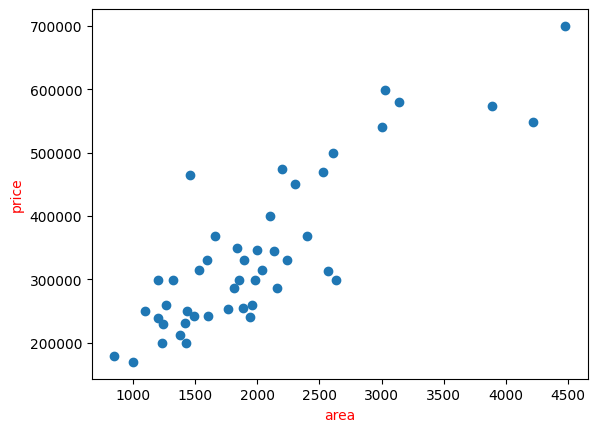

In [ ]:
plt.xlabel("area",color = 'red')
plt.ylabel("price",color = 'red')
plt.scatter(df.area,df.price)

In [ ]:
lr= linear_model.LinearRegression()
lr.fit(df[['area', 'rooms']],df.price)

LinearRegression()

In [ ]:
lr.predict([[4300,5]])   # NOT DataFrame

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([644513.71225695])

In [ ]:
lr.score( df[['area', 'rooms']],df.price)


0.7329450180289141

### Training a new model with 'area' and 'rooms' features

In [ ]:
lr_multi = linear_model.LinearRegression()
lr_multi.fit(df[['area', 'rooms']], df.price)

LinearRegression()

### Evaluating the new model's accuracy

In [ ]:
new_score = lr_multi.score(df[['area', 'rooms']], df.price)
print(f"New model accuracy with 'area' and 'rooms': {new_score:.4f}")

New model accuracy with 'area' and 'rooms': 0.7329


### Exploring Polynomial Features to Improve Accuracy

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (degree 2 for example)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[['area', 'rooms']])

# Train a new Linear Regression model on the polynomial features
lr_poly = linear_model.LinearRegression()
lr_poly.fit(X_poly, df.price)

# Evaluate the new model
poly_score = lr_poly.score(X_poly, df.price)
print(f"New model accuracy with polynomial features (degree 2): {poly_score:.4f}")

New model accuracy with polynomial features (degree 2): 0.7547


### Using a more advanced model: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 trees, random_state for reproducibility
rf_model.fit(df[['area', 'rooms']], df.price)

# Evaluate the Random Forest model
rf_score = rf_model.score(df[['area', 'rooms']], df.price)
print(f"Random Forest Regressor accuracy: {rf_score:.4f}")

Random Forest Regressor accuracy: 0.9428


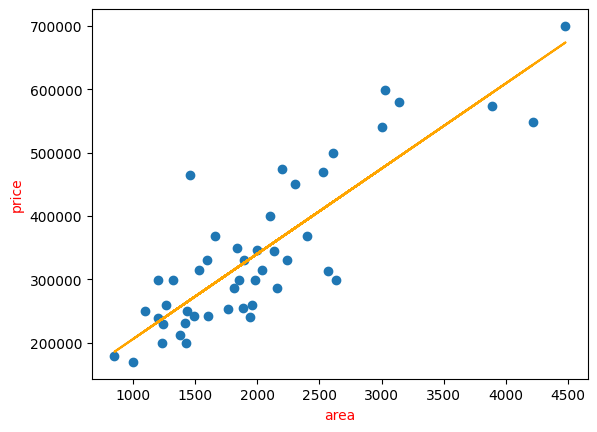

In [ ]:
plt.xlabel("area",color = 'red')
plt.ylabel("price",color = 'red')
plt.scatter(df.area,df.price)
plt.plot(df.area,lr.predict(df[['area']]),color = 'orange')